In [4]:
import os
import pickle
import json
import sys
import numpy as np
import re

sys.path.append('/orcd/data/jhm/001/om2/jmhicks/projects/TextureStreaming/code/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/src/model/')
sys.path.append("/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/")


from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params, statistics_set, texture_dataset
from texture_prior.utils import path

from encoders import *
from utls.plotting import ensure_dir
from utls.loading import load_results_with_exclusion_2, move_sequences_to_used, load_results_with_exclusion_no_dropping
from utls.runners import run_experiment_scores
from utls.runners_v2 import (
    run_experiment_grid,
    run_experiment_scores,
    run_experiment_scores_itemwise,
    run_experiment_itemwise_hits_fas,
    make_noise_schedule
)

from scipy.stats import spearmanr, pearsonr


from utls.analysis_helpers import rocs_across_noise, compute_scaling_vs_human
from utls.analysis_helpers import auroc_to_dprime, compute_model_dprime_curve
from utls.analysis_helpers import roc_for_isi, auroc_to_dprime
from utls.plotting import plot_across_noise, plot_noise_overlays
from utls.io_utils import make_model_save_dir, save_all_figures, save_single_figure, save_runs_summary
from utls.roc_utils import roc_from_arrays, plot_roc, roc_from_arrays_with_threshold
from utls.runners_utils import *

def pool_itemwise_responses(human_runs):
    """
    Pool itemwise hit / FA responses across participants.

    Parameters
    ----------
    human_runs : list[dict]
        Output of convert_human_to_model_struct for each participant

    Returns
    -------
    pooled_hits_by_isi : defaultdict
        pooled_hits_by_isi[isi][stim] -> list of responses

    pooled_fas_by_isi : defaultdict
        pooled_fas_by_isi[isi][stim] -> list of responses
    """

    pooled_hits_by_isi = defaultdict(lambda: defaultdict(list))
    pooled_fas_by_isi  = defaultdict(lambda: defaultdict(list))

    for run in human_runs:

        # ---- HITS ----
        for isi, stim_dict in run["item_hits_by_isi"].items():
            for stim, responses in stim_dict.items():
                pooled_hits_by_isi[isi][stim].extend(responses)

        # ---- FALSE ALARMS ----
        for isi, stim_dict in run["item_fas_by_isi"].items():
            for stim, responses in stim_dict.items():
                pooled_fas_by_isi[isi][stim].extend(responses)

    return pooled_hits_by_isi, pooled_fas_by_isi

def convert_human_to_model_struct(main_exp, *, drop_isi_zero=True):
    """
    Convert a participant dataframe into model-compatible format
    with added ITEM-LEVEL response tracking.

    Parameters
    ----------
    main_exp : pandas.DataFrame
        Must include columns:
        ['stimulus', 'repeat', 'isi', 'response']

    drop_isi_zero : bool
        If True, itemwise stats ignore ISI == 0

    Returns
    -------
    dict
        Model-style output + itemwise response maps
    """

    # ---- Convert core columns ----
    stimulus = np.asarray(main_exp["stimulus"])
    is_repeat = np.asarray(main_exp["repeat"] == "true", dtype=bool)
    isi = np.asarray(main_exp["isi"], dtype=float)
    response = np.asarray(main_exp["response"], dtype=int)

    T_max = len(main_exp)

    # ---- Trialwise hit / FA vectors (unchanged) ----
    hits = response[is_repeat]
    fas  = response[~is_repeat]

    # ---- ISI → hit distributions (unchanged, but explicit) ----
    isi_hit_dists = defaultdict(list)
    for t, (rep, isi_val, resp) in enumerate(zip(is_repeat, isi, response)):
        if not rep:
            continue

        isi_hit_dists[int(isi_val)].append((float(resp), t))

    # ---- FA-by-time (unchanged) ----
    fa_by_t = [[] for _ in range(T_max)]
    for t, (rep, resp) in enumerate(zip(is_repeat, response)):
        if not rep:
            fa_by_t[t].append(float(resp))

    # ------------------------------------------------------------------
    # NEW: ITEM-LEVEL RESPONSE TRACKING
    # ------------------------------------------------------------------

    item_hits_by_isi = defaultdict(lambda: defaultdict(list))
    item_fas_by_isi  = defaultdict(lambda: defaultdict(list))

    for stim, rep, isi_val, resp in zip(stimulus, is_repeat, isi, response):

        if drop_isi_zero and isi_val == 0:
            continue

        isi_key = int(isi_val)

        if rep:
            item_hits_by_isi[isi_key][stim].append(float(resp))
        else:
            item_fas_by_isi[isi_key][stim].append(float(resp))

    return {
        # ---- existing fields ----
        "hits": np.asarray(hits, float),
        "fas": np.asarray(fas, float),
        "isi_hit_dists": isi_hit_dists,
        "fa_by_t": fa_by_t,
        "T_max": T_max,
        "score_type": "likelihood",
        "noise_mode": "human",

        # ---- new fields ----
        "item_hits_by_isi": item_hits_by_isi,
        "item_fas_by_isi": item_fas_by_isi,
    }

def load_experiment_data(which_task, which_isi, is_multi, old=False):
    """
    Returns:
        experiment_list (list[list[str]])
        all_files       (list[str])
        name_to_idx     (dict)
        human_runs      (list)
    """

    batch_size = 8
    active_batch_size = batch_size*18
    if not is_multi:
        tasks = ["ind-nature-len120", "global-music-len120",
                 "atexts-len120", "nhs-region-len120"]
        base_path = f"/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/{{}}/sequences/isi_{which_isi}/len120/"
    else:
        tasks = ["env-sounds", "glob-music", "atexts", "nhs-region-len120"]
        base_path = "/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/{}/sequences/len120_multi/"

    task_name = tasks[which_task]

    # map tasks → set names
    seqs_paths = {
        tasks[0]: "mem_exp_ind-nature_2025",
        tasks[1]: "global-music-2025-n_80",
        tasks[2]: "mem_exp_atexts_2025",
        tasks[3]: "nhs-region-n_80",
    }

    hr_task_names = { tasks[0]: "Industrial and Nature", 
                     tasks[1]: "Globalized Music",
                     tasks[2]: "Auditory Textures",
                     tasks[3]: " 'Natural History of Song' "}

    hr_task_name = hr_task_names[task_name]

    # load human data
    if not is_multi:
        exps, seqs, fnames, _, _, _ = load_results_with_exclusion_no_dropping(
            f"/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/bjmedina/experiments/bolivia_2025/results/"
            f"isi_{which_isi}/{task_name}",
            min_dprime=2, min_trials=120, skip_len60=True,
            verbose=False, return_skipped=True)
    else:
        exps, seqs, fnames, _, _, _ = load_results_with_exclusion_no_dropping(
            f"/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/bjmedina/experiments/{task_name}/results/"
            f"{task_name}/len120_multi",
            min_dprime=2, min_trials=120, skip_len60=True,
            verbose=False, return_skipped=True)

    # ---- group indices by sequence ----
    seq_to_indices = defaultdict(list)
    for i, s in enumerate(seqs):
        seq_to_indices[s].append(i)
    
    # ---- randomly keep one index per sequence ----
    keep = [random.choice(idxs) for idxs in seq_to_indices.values()]
    
    # ---- apply filter ----
    exps   = [exps[i]   for i in keep]
    seqs   = [seqs[i]   for i in keep]
    fnames = [fnames[i] for i in keep]

    if not old:

        current_batch = refresh_unused_batch(base_path.format(seqs_paths[task_name]), 8)
        
        # ---- extract seq numbers ----
        seqnums = [int(re.search(r"seq(\d+)", s).group(1)) for s in seqs]
        
        # ---- group seqnums by batch ----
        batch_to_seqnums = defaultdict(set)
        for n in seqnums:
            batch_id = (n - 1) // batch_size
            batch_to_seqnums[batch_id].add(n)
        
        # ---- determine which batches are complete ----
        complete_batches = {
            b for b, nums in batch_to_seqnums.items()
            if nums == set(range(b * batch_size + 1, b * batch_size + batch_size + 1))
        }
        
        # ---- filter everything in lockstep ----
        keep = [
            i for i, n in enumerate(seqnums)
            if (n - 1) // batch_size in complete_batches
        ]
        
        exps   = [exps[i] for i in keep]
        seqs   = [seqs[i] for i in keep]
        fnames = [fnames[i] for i in keep]

    # load stimulus sequences
    experiment_list = []
    seq_dir = base_path.format(seqs_paths[task_name])
    stim_base = "/".join(seq_dir.split("/")[:-3])

    for seq in seqs:
        with open(seq_dir + seq, "r") as f:
            data = json.load(f)
        stim_files = [stim_base + "/" + s for s in data["filenames_order"]]
        experiment_list.append(stim_files)

    # collapse all unique files
    all_files = sorted({fn for seq in experiment_list for fn in seq})
    name_to_idx = {fn: i for i, fn in enumerate(all_files)}

    # convert human runs
    human_runs = [convert_human_to_model_struct(e) for e in exps]

    return experiment_list, all_files, name_to_idx, human_runs, task_name, hr_task_name

def load_all_bestmodel_pkls(
    fits_dir,
    *,
    required_core=("params", "run_out"),
    metric_keys=None,
    verbose=True,
):
    """
    Load bestmodel *.pkl files into a flat list of records.

    Assumptions:
      - each pkl contains ONE model record
      - record contains at least `params` and `run_out`

    Does NOT assume:
      - a specific metric (e.g. nmse)
      - specific top-level schema

    Parameters
    ----------
    required_core : tuple of str
        Keys that must exist in each pickle.
    metric_keys : iterable of str or None
        Metric names to extract if present (e.g. ["nmse", "mse_mean"]).
        If None, metrics are inferred automatically.
    """

    records = []

    for fname in sorted(os.listdir(fits_dir)):
        if not fname.endswith(".pkl"):
            continue

        path = os.path.join(fits_dir, fname)
        if verbose:
            print(f"Loading {fname}")

        with open(path, "rb") as f:
            rec = pickle.load(f)

        # ----------------------------
        # Sanity checks
        # ----------------------------
        missing = set(required_core) - rec.keys()
        if missing:
            raise ValueError(f"{fname} missing required keys: {missing}")

        params = rec["params"]

        # ----------------------------
        # Metrics (flexible)
        # ----------------------------
        metrics = {}

        if metric_keys is not None:
            for k in metric_keys:
                if k in rec:
                    metrics[k] = rec[k]
                elif k in rec.get("metrics", {}):
                    metrics[k] = rec["metrics"][k]
        else:
            # auto-infer numeric scalars
            for k, v in rec.items():
                if isinstance(v, (int, float)):
                    metrics[k] = v
            for k, v in rec.get("metrics", {}).items():
                if isinstance(v, (int, float)):
                    metrics[k] = v

        # ----------------------------
        # Identity extraction
        # ----------------------------
        def get_field(name):
            return rec.get(name) or params.get(name)

        record = {
            # raw
            "params": params,
            "run_out": rec["run_out"],
            "model_dp": rec.get("model_dp"),

            # metrics (plural!)
            "metrics": metrics,

            # standardized identity
            "encoder": get_field("encoder"),
            "layer": get_field("layer"),
            "metric": params.get("metric"),
            "noise_mode": params.get("noise_mode"),
            "t_step": params.get("t_step"),
            "stimulus_set": get_field("stimulus_set"),

            # provenance
            "source_file": fname,
            "raw_record": rec,   # full preservation
        }

        records.append(record)

    return records

def inspect_bestmodel_pkl(path, max_keys=10):
    import pickle

    with open(path, "rb") as f:
        obj = pickle.load(f)

    print(f"\nFILE: {path}")
    print(f"Type: {type(obj)}")

    if isinstance(obj, list):
        print(f"List length: {len(obj)}")
        if len(obj) > 0 and isinstance(obj[0], dict):
            print("Keys in first element:")
            for k in list(obj[0].keys())[:max_keys]:
                print(f"  - {k}")

    elif isinstance(obj, dict):
        print(f"Dict keys (showing up to {max_keys}):")
        for k in list(obj.keys())[:max_keys]:
            print(f"  - {k}")
        first_val = next(iter(obj.values()))
        print("Value type:", type(first_val))
        if isinstance(first_val, dict):
            print("Keys in value:")
            for k in list(first_val.keys())[:max_keys]:
                print(f"  - {k}")

    else:
        print("Unknown object structure")

    return obj

from collections import defaultdict
def group_by_key(records, key):
    grouped = defaultdict(list)
    for rec in records:
        grouped[rec[key]].append(rec)
    return grouped


def evaluate_grid_results(
    grid_results,
    human_curve,
    isis,
    *,
    score_fn="mse_mean",
    isi_indices=[1,2,3,4,5,6,7],
    overwrite=True,
):
    """
    Ensure each record has:
      - model_dp
      - metrics
      - score

    Compatible with:
      - raw grid search records
      - loaded bestmodel pkls
      - post-hoc filtered records
    """

    human_curve = np.asarray(human_curve)

    for rec in grid_results:

        # ----------------------------------
        # 1. model_dp
        # ----------------------------------
        if overwrite or "model_dp" not in rec:
            run_out = rec.get("results", rec.get("run_out"))
            if run_out is None:
                raise KeyError("Record must contain 'results' or 'run_out'")

            model_dp = compute_model_dprime_for_run(run_out, isis)
            rec["model_dp"] = model_dp
        else:
            model_dp = rec["model_dp"]

        # ----------------------------------
        # 2. metrics
        # ----------------------------------
        if overwrite or "metrics" not in rec:
            mse_per_isi = (model_dp - human_curve) ** 2

            if isi_indices is None:
                mse_mean = float(np.mean(mse_per_isi))
            else:
                mse_mean = float(np.mean(mse_per_isi[isi_indices]))

            metrics = {
                "mse_per_isi": mse_per_isi,
                "mse_early": float(np.mean(mse_per_isi[1:])),
                "mse_late": float(np.mean(mse_per_isi[2:])),
                "mse_mean": mse_mean,
                "score": rec["score"]
            }

            rec["metrics"] = metrics
        else:
            metrics = rec["metrics"]

        # ----------------------------------
        # 3. score
        # ----------------------------------
        if score_fn not in metrics:
            raise KeyError(
                f"Requested score_fn '{score_fn}' not in metrics: {list(metrics)}"
            )

        rec[score_fn] = metrics[score_fn]

def plot_best_models(
    best_models,
    human_curve,
    isis,
    *,
    score_label="Score",
    hr_task_name="",
    encoder_name="",
):
    """
    Plot best models with:
      - color = representation (encoder × layer)
      - alpha = score (lower = darker)
      - linestyle = noise mode
    """

    plt.figure(figsize=(13, 9))

    # -------------------------
    # Human reference
    # -------------------------
    plt.plot(
        isis,
        human_curve,
        "o-k",
        linewidth=3,
        label="Human",
        zorder=10,
    )

    # -------------------------
    # Score → alpha mapping
    # -------------------------
    scores = np.array([rec["score"] for rec in best_models.values()])
    smin, smax = np.nanmin(scores), np.nanmax(scores)

    def score_to_alpha(score):
        # best → alpha≈1, worst → alpha≈0.3
        if smax == smin:
            return 0.8
        return 0.3 + 0.7 * (smax - score) / (smax - smin)

    # -------------------------
    # Representation → color
    # -------------------------
    repr_keys = sorted({
        (
            rec["params"].get("encoder", "unknown"),
            rec["params"].get("layer"),
        )
        for rec in best_models.values()
    })

    cmap = plt.get_cmap("tab10")
    repr_to_color = {
        rk: cmap(i % 10)
        for i, rk in enumerate(repr_keys)
    }

    # -------------------------
    # Plot models
    # -------------------------
    for (metric, noise_mode), rec in best_models.items():

        p = rec["params"]
        enc = p.get("encoder", "unknown")
        layer = p.get("layer")
        score = rec["score"]

        color = repr_to_color[(enc, layer)]
        alpha = score_to_alpha(score)

        linestyle = "--" if noise_mode == "constant" else "-"

        label = f"{noise_mode} | {score_label}={score:.3f}"

        plt.plot(
            isis,
            rec["model_dp"],
            linestyle,
            color=color,
            alpha=alpha,
            linewidth=2,
            marker="o",
            label=label,
        )

    # -------------------------
    # Formatting
    # -------------------------
    plt.xlabel("ISI (s)")
    plt.ylabel("d′")
    plt.grid(True, alpha=0.3)
    plt.title(
        f"{hr_task_name}\nBest Models",
        fontsize=14,
    )

    plt.legend(
        fontsize=8,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
    )

    plt.tight_layout(rect=[0, 0, 0.78, 1])
    plt.show()

def get_best_model(records):
    """
    Return the single best model (min score).
    """
    valid = [r for r in records if np.isfinite(r["score"])]
    return min(valid, key=lambda r: r["score"]) if valid else None


def get_best_overall(records, k=0):
    """
    Return the k-th best model by score.
    """
    valid = [r for r in records if np.isfinite(r['metrics']["score"])]
    valid = sorted(valid, key=lambda r: r['metrics']["score"])
    return valid[k] if len(valid) > k else None

def plot_best_constant_vs_two_regime_by_tstep(
    task_name,
    task_records,
    human_curve,
    isis,
    savedir=None,
):
    """
    One plot for one stimulus set:
      - best constant model
      - best two-regime model at each t_step
      - human curve
    """

    # ----------------------------
    # Split by noise mode
    # ----------------------------
    const_recs = [r for r in task_records
                  if r["params"]["noise_mode"] != "two-regime"]

    two_regime_recs = [r for r in task_records
                       if r["params"]["noise_mode"] == "two-regime"]

    # ----------------------------
    # Best CONSTANT model
    # ----------------------------
    best_const = get_best_model(const_recs, human_curve, isis)

    # ----------------------------
    # Best TWO-REGIME per t_step
    # ----------------------------
    best_two_by_t = {}
    by_t = group_by_key(two_regime_recs, "t_step")

    for t_step, recs in by_t.items():
        if t_step is None:
            continue
        best = get_best_model(recs, human_curve, isis)
        if best is not None:
            best_two_by_t[t_step] = best

    # ----------------------------
    # Plot
    # ----------------------------
    plt.figure(figsize=(6, 4))

    # Human
    plt.plot(isis, human_curve, "o-k", lw=3, label="Human")

    # Constant
    if best_const is not None:
        plt.plot(
            isis,
            best_const["model_dp"],
            "--",
            lw=2,
            label=f"Constant (best)"
        )

    # Two-regime curves
    for t_step in sorted(best_two_by_t):
        rec = best_two_by_t[t_step]
        plt.plot(
            isis,
            rec["model_dp"],
            "-o",
            alpha=0.8,
            label=f"Two-regime t={t_step}"
        )

    plt.xlabel("ISI")
    plt.ylabel("d′")
    plt.title(f"{task_name}: Best Constant vs Two-Regime")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)

    if savedir:
        ensure_dir(savedir)
        plt.savefig(
            f"{savedir}/best_constant_vs_two_regime_by_tstep.png",
            dpi=200
        )

    plt.show()

def correlate_itemwise_rates(
    rates_a,
    rates_b,
    *,
    method="spearman",
    return_vectors=False
):
    """
    Correlate itemwise rates between two groups (e.g., human vs model).

    Parameters
    ----------
    rates_a : dict[str, float]
        Item -> rate (HR or FA) for group A

    rates_b : dict[str, float]
        Item -> rate (HR or FA) for group B

    method : {'spearman', 'pearson'}
        Correlation type

    return_vectors : bool
        If True, also return aligned x, y vectors and item labels

    Returns
    -------
    corr : float
        Correlation coefficient

    pval : float
        Two-sided p-value

    (optional)
    x, y : np.ndarray
        Aligned rate vectors

    items : list[str]
        Item labels (aligned order)
    """

    # ---- align items safely ----
    items = sorted(set(rates_a) & set(rates_b))

    if len(items) < 3:
        raise ValueError("Not enough overlapping items to correlate")

    x = np.asarray([rates_a[i] for i in items], float)
    y = np.asarray([rates_b[i] for i in items], float)

    # ---- compute correlation ----
    if method == "spearman":
        corr, pval = spearmanr(x, y)
    elif method == "pearson":
        corr, pval = pearsonr(x, y)
    else:
        raise ValueError("method must be 'spearman' or 'pearson'")

    if return_vectors:
        return corr, pval, x, y, items

    return corr, pval


def threshold_for_target_hr(fpr, tpr, thresholds, target_hr):
    idx = np.nanargmin(np.abs(tpr - target_hr))
    return thresholds[idx], fpr[idx], tpr[idx]

def threshold_for_target_fa(fpr, tpr, thresholds, target_fa):
    """
    Find threshold whose false alarm rate (FPR) is closest to target_fa.

    Returns:
        threshold
        fpr_at_threshold
        tpr_at_threshold
    """
    fpr = np.asarray(fpr)
    tpr = np.asarray(tpr)
    thresholds = np.asarray(thresholds)

    idx = np.nanargmin(np.abs(fpr - target_fa))
    return thresholds[idx], fpr[idx], tpr[idx]

def apply_threshold(scores, threshold, score_type="distance"):
    """
    Convert scores to binary yes/no decisions.

    score_type:
        - "distance": smaller = more similar → YES if score <= threshold
        - "similarity": larger = more similar → YES if score >= threshold
    """
    scores = np.asarray(scores)

    if score_type == "distance":
        return scores < threshold
    elif score_type == "similarity":
        return scores > threshold
    else:
        raise ValueError(f"Unknown score_type: {score_type}")

def compute_itemwise_hit_fa_rates(
    item_hits,
    item_fas,
    threshold,
    score_type="distance",
):
    """
    Compute itemwise hit rate and false alarm rate.

    Returns:
        hit_rates: dict[item] -> float
        fa_rates:  dict[item] -> float
    """
    hit_rates = {}
    fa_rates = {}

    # --------------------
    # Hits
    # --------------------
    for item, scores in item_hits.items():
        stim = item.split("/")[-1]
        if len(scores) == 0:
            hit_rates[stim] = np.nan
            continue

        yes = apply_threshold(scores, threshold, score_type)
        hit_rates[stim] = np.mean(yes)

    # --------------------
    # False alarms
    # --------------------
    for item, scores in item_fas.items():
        stim = item.split("/")[-1]
        if len(scores) == 0:
            fa_rates[stim] = np.nan
            continue

        yes = apply_threshold(scores, threshold, score_type)
        fa_rates[stim] = np.mean(yes)

    return hit_rates, fa_rates

def plot_itemwise_fa_vs_hit(item_hr, item_far, title="", ax=None):
    """
    Scatter plot of item-wise false alarm rate vs hit rate.
    """

    # align items
    items = sorted(set(item_hr) & set(item_far))

    hr = np.array([item_hr[i] for i in items], float)
    fa = np.array([item_far[i] for i in items], float)

    valid = ~(np.isnan(hr) | np.isnan(fa))
    hr = hr[valid]
    fa = fa[valid]

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    ax.scatter(hr, fa, alpha=0.7, color='m')
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_ylabel("False Alarm Rate")
    ax.set_xlabel("Hit Rate")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

    if ax is None:
        plt.tight_layout()
        plt.show()

def get_best_for_layer(records, human_curve, isis, layer, *, score_fn):
    """
    Return best model for a given layer, using rec["score"].
    """

    evaluate_grid_results(
        records,
        human_curve,
        isis,
        score_fn=score_fn,
        overwrite=True,   # IMPORTANT
    )

    valid = [
        r for r in records
        if np.isfinite(r['metrics']["score"]) and r["params"].get("layer") == layer
    ]

    return min(valid, key=lambda r: r['metrics']["score"]) if valid else None

tasks = {
    0: "ind-nature",
    1: "global-music",
    2: "atexts",
}

In [2]:
# ---- load model registry ----
fits_dir = "/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/fits/fits_v12_three-regime_best"
results_root = "/orcd/data/ta/jhm/001/om2/bjmedina/auditory-memory/memory/"
all_opt_results = load_all_bestmodel_pkls(fits_dir)

print(f"Loaded {len(all_opt_results)} models")

# ---- enrich records (IMPORTANT) ----
for rec in all_opt_results:
    rec["t_step"] = rec["params"].get("t_step", None)

# ---- grouping (THIS IS WHERE YOUR QUESTION POINTS) ----
models_by_noise = group_by_key(all_opt_results, "noise_mode")

models_by_noise_task_repr = {}
for noise_mode, noise_recs in models_by_noise.items():
    by_task = group_by_key(noise_recs, "stimulus_set")

    models_by_noise_task_repr[noise_mode] = {}
    for task, task_recs in by_task.items():
        by_repr = group_by_key(task_recs, "encoder")
        models_by_noise_task_repr[noise_mode][task] = by_repr

models_by_noise_task_repr_t = {}

for noise_mode, task_dict in models_by_noise_task_repr.items():
    models_by_noise_task_repr_t[noise_mode] = {}

    for task, repr_dict in task_dict.items():
        models_by_noise_task_repr_t[noise_mode][task] = {}

        for enc, enc_recs in repr_dict.items():
            if noise_mode == "two-regime":
                by_t = group_by_key(enc_recs, "t_step")
            else:
                by_t = {None: enc_recs}

            print("encoder", enc)
            models_by_noise_task_repr_t[noise_mode][task][enc] = by_t

Loading atexts-kell2018-relu0_cosine_three-regime_t5.pkl
Loading atexts-kell2018-relu1_cosine_three-regime_t5.pkl
Loading atexts-kell2018-relu2_cosine_three-regime_t5.pkl
Loading atexts-kell2018-relu3_cosine_three-regime_t5.pkl
Loading atexts-kell2018-relu4_cosine_three-regime_t5.pkl
Loading atexts-kell2018-relufc_cosine_three-regime_t5.pkl
Loading atexts-resnet50-avgpool_cosine_three-regime_t5.pkl
Loading atexts-resnet50-conv1_relu1_cosine_three-regime_t5.pkl
Loading atexts-resnet50-input_after_preproc_cosine_three-regime_t5.pkl
Loading atexts-resnet50-layer1_cosine_three-regime_t5.pkl
Loading atexts-resnet50-layer2_cosine_three-regime_t5.pkl
Loading atexts-resnet50-layer3_cosine_three-regime_t5.pkl
Loading atexts-resnet50-layer4_cosine_three-regime_t5.pkl
Loading env-sounds-kell2018-relu0_cosine_three-regime_t5.pkl
Loading env-sounds-kell2018-relu1_cosine_three-regime_t5.pkl
Loading env-sounds-kell2018-relu2_cosine_three-regime_t5.pkl
Loading env-sounds-kell2018-relu3_cosine_three-re

0 ind-nature


/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:210: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


score 0.11396629671100302
human d' on ISI=16 exp [3.15622387 1.73792082]
LOADING FROM /orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_directories/kell2018_word_speaker_audioset/


/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:1351: SyntaxWarning: invalid escape sequence '\s'
  f"$\sigma_0$={params['sigma0']:.2f}  |  $\sigma_1$={params['sigma1']:.2f}  |  mode={params['noise_mode']}"
/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:1351: SyntaxWarning: invalid escape sequence '\s'
  f"$\sigma_0$={params['sigma0']:.2f}  |  $\sigma_1$={params['sigma1']:.2f}  |  mode={params['noise_mode']}"
/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:1584: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f"{title} ($\mu={mu:.3f}$)")


KeyError: 'time_avg'

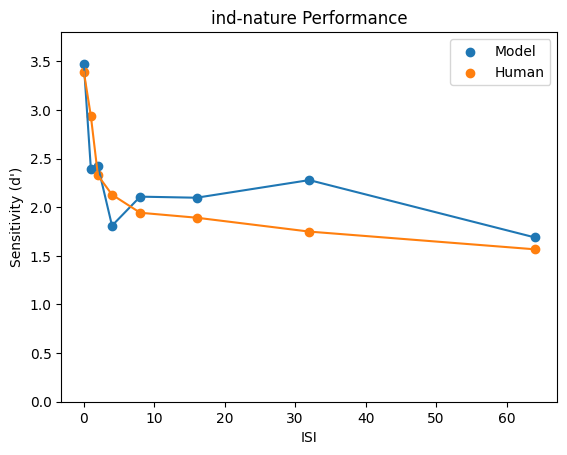

In [5]:
isis = [0, 1, 2, 4, 8, 16, 32, 64]

which_isi = 16
isis_single = [0, which_isi]
is_multi = False

fa_rates = {0: 0.2, 1: 0.2, 2: 0.4}

top_k = 0

layer = "relu4"
score_fn="score"

for which_task, task_label in tasks.items():

    print(which_task, task_label)
    # ---- load MULTI-ISI experiment ----
    exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = \
        load_experiment_data(which_task, None, True, False)
    

    human_curve_multi = compute_human_curve(human_runs, True, None)

    # ---- collect all best models for this task ----
    task_records = [
        r for r in all_opt_results
        if r["stimulus_set"] == hr_task_name
    ]


    if not task_records:
        continue

    evaluate_grid_results(
        task_records,
        human_curve_multi,
        isis,
        score_fn=score_fn, 
        overwrite=False# or mse_mean / mse_early
    )
    
    task_records = [
        r for r in task_records
        if np.isfinite(r['metrics']["score"])
    ]
    
    task_records = sorted(task_records, key=lambda r: r['metrics']["score"])

    for model in task_records:
        model['params']['encoder'] = model['encoder'].split("-")[0]
        model['params']['layer']   = model['encoder'].split("-")[-1]

        if "texture" in model['params']['encoder']:
            pc_dims = int(re.search(r'\d+', model['params']['layer']).group())
            model['params']['pc_dims'] = pc_dims
        else:
            model['params']['pc_dims'] = None


    if layer == None:
        # ---- pick best multi-ISI model ----
        best_model = get_best_overall(
            task_records,
            human_curve_multi,
        )
    else:
       best_model = get_best_for_layer(
        task_records,
        human_curve_multi,
        isis,
        layer=layer,
        score_fn=score_fn,   # or "mse_mean", "mse_early"
    )

    print("score", best_model['metrics']['score'])

    
    plt.figure()
    plt.scatter(isis, best_model['model_dp'], label="Model")
    plt.plot(isis, best_model['model_dp'])
    
    plt.scatter(isis, human_curve_multi, label="Human")
    plt.plot(isis, human_curve_multi)
    
    plt.title(f"{task_label} Performance")
    plt.ylabel("Sensitivity (d')")
    plt.xlabel("ISI")
    plt.legend()
    plt.ylim([0, 3.8])
    
    # ---- load single-ISI experiment ----
    exp_list, all_files_s, name_to_idx, human_runs, task_name, hr_task_name = \
        load_experiment_data(which_task, which_isi, False, old=True)

    all_files_s = [s.replace("/sequences", "") for s in all_files_s]

    pooled_item_hits_by_isi, pooled_item_fas_by_isi = pool_itemwise_responses(human_runs)
    
    human_curve = compute_human_curve(human_runs, is_multi, which_isi)

    item_hr_human, item_far_human = compute_itemwise_hit_fa_rates(
            pooled_item_hits_by_isi[which_isi],
            pooled_item_fas_by_isi[-1],
            1.0,
            score_type="similarity"
    )

    print("human d' on ISI=16 exp", human_curve)

    if best_model is None:
        continue

    # ---- build encoder once ----
    encoder_cfg = dict(
        encoder_type=best_model["params"]["encoder"],
        model_name=best_model["params"]["encoder"],
        layer=best_model["params"].get("layer"),
        task="word_speaker_audioset"
            if best_model["params"]["encoder"] != "texture"
            else "audioset",
        statistics_dict=statistics_set.statistics,
        model_params=model_params,
        pc_dims=best_model["params"]["pc_dims"],
        sr=20000,
        duration=2.0,
        rms_level=0.05,
        device="cuda",
    )

    encoder = build_encoder(encoder_cfg)
    X = encode_stimuli(encoder, all_files_s)

    params = best_model["params"]
    
    ## NEEDS TO BE FIXED TO THREE PARAMETER
    run_out = run_experiment_scores_itemwise(
            sigma0=params["sigma0"],
            sigma1=params.get("sigma1", None),
            sigma2=params.get("sigma2", None),
            t_step=params.get("t_step", None),
            rate=params.get("rate", None),
            noise_mode=params.get("noise_mode", None),
            metric=params.get("metric", None),
            X0=X,
            name_to_idx=name_to_idx,
            experiment_list=exp_list,
            debug=False,
        )

    metric=params.get("metric", None)
    sigma1=params.get("sigma1", None)
    sigma2=params.get("sigma2", None)
    t_step=params.get("t_step", None)
    sigma0=params["sigma0"]
    noise_mode=params.get("noise_mode", None)
    encoder=best_model["params"]["encoder"]
    layer=best_model["params"]["layer"]
    
    repeat_scores_humans = []
    non_repeat_scores_humans = []
    
    repeat_scores, non_repeat_scores = [], []
    for key in run_out['item_hits'].keys():
        repeat_scores.extend(run_out['item_hits'][key])
        non_repeat_scores.extend(run_out['item_fas'][key])

    # ---- human repeat (hit) responses ----
    for stim in pooled_item_hits_by_isi[which_isi].keys():
        repeat_scores_humans.extend(pooled_item_hits_by_isi[which_isi][stim])
    
    # ---- human non-repeat (false alarm) responses ----
    for stim in pooled_item_fas_by_isi[-1].keys():
        non_repeat_scores_humans.extend(pooled_item_fas_by_isi[-1][stim])

    repeat_scores_humans, non_repeat_scores_humans = 1-np.array(repeat_scores_humans), 1-np.array(non_repeat_scores_humans)
    fpr_h, tpr_h, thresholds_h = roc_from_arrays_with_threshold(repeat_scores_humans, non_repeat_scores_humans)

    thres_index = np.where(thresholds_h==1)[0][0]
    print(fpr_h, tpr_h, thresholds_h)
    
    plt.figure()
    plt.hist(repeat_scores, color='g', label="Repeat Trials", bins=100, alpha=0.5)
    plt.hist(non_repeat_scores, color='r', label="Non-repeat Trials", bins=100, alpha=0.5)
    plt.title(f"Distribution of scores \n {noise_mode}-{metric}-{encoder}-{layer}-t={t_step}")
    plt.legend()

    repeat_scores, non_repeat_scores = np.array(repeat_scores), np.array(non_repeat_scores)
    fpr, tpr, thresholds = roc_from_arrays_with_threshold(repeat_scores, non_repeat_scores)

    plt.figure()
    plt.title(f"ROC for\n{noise_mode}-{metric}-{encoder}-{layer}-t={t_step}")
    plt.plot(fpr, tpr, label="Model")
    plt.plot(fpr_h, tpr_h, label="Humans")
    
    plt.ylim([0,1])
    plt.xlim([0,1])
    
    plt.legend()

    threshold, fpp, tpp = threshold_for_target_fa(fpr, tpr, thresholds, fpr_h[thres_index])

    threshold = -threshold # from ROC target HR
    score_type = run_out["score_type"]
    
    item_hits = run_out["item_hits"]
    item_fas  = run_out["item_fas"]
    
    item_hr, item_far = compute_itemwise_hit_fa_rates(
        item_hits,
        item_fas,
        threshold,
        score_type=score_type,
    )
    
    plt.figure()

    plot_itemwise_fa_vs_hit(
        item_hr,
        item_far,
        title=f"{task_label} Item-wise FA vs Hit (Model). Threshold={threshold:.2f}",
    )

    plot_itemwise_fa_vs_hit(
        item_hr_human, item_far_human,
        title=f"{task_label} Item-wise FA vs Hit (Human)",
    )
    
    rho, p, x, y, items = correlate_itemwise_rates(
    item_hr_human,
    item_hr,
    return_vectors=True
    )
    
    plt.figure(figsize=(4,4))
    plt.scatter(x, y, alpha=0.7, color='g')
    plt.plot([0,1], [0,1], 'k--', lw=1)
    plt.xlabel("Human item HR")
    plt.ylabel("Model item HR")
    plt.title(f"Spearman ρ = {rho:.2f}")
    plt.tight_layout()
    plt.show()

    plt.figure()

    rho, p, x, y, items = correlate_itemwise_rates(
        item_far_human,
        item_far,
        return_vectors=True
    )
    
    plt.figure(figsize=(4,4))
    plt.scatter(x, y, alpha=0.7, color='r')
    plt.plot([0,1], [0,1], 'k--', lw=1)
    plt.xlabel("Human item FAR")
    plt.ylabel("Model item FAR")
    plt.title(f"Spearman ρ = {rho:.2f}")
    plt.tight_layout()
    plt.show()


13
{'mse_per_isi': array([0.07324483, 0.00621588, 0.07817325, 0.03064381, 0.00059415,
       0.02182337, 0.00015412, 0.1370103 ]), 'mse_early': 0.03923069702586337, 'mse_late': 0.04473316647520927, 'mse_mean': 0.03923069702586337, 'score': 0.036933805835805744} relu2
{'mse_per_isi': array([0.00664963, 0.29447756, 0.00929507, 0.10162992, 0.02741029,
       0.04216901, 0.28036336, 0.0149917 ]), 'mse_early': 0.11004812760153661, 'mse_late': 0.0793098895248536, 'mse_mean': 0.11004812760153661, 'score': 0.11396629671100302} relu4
{'mse_per_isi': array([0.0240086 , 0.86907442, 0.02251285, 0.04716856, 0.01464725,
       0.00749354, 0.03313217, 0.07852758]), 'mse_early': 0.15322233794668175, 'mse_late': 0.03391365819270791, 'mse_mean': 0.15322233794668175, 'score': 0.182098141913919} relu3
{'mse_per_isi': array([0.46420184, 0.53889006, 0.29722288, 0.30570567, 0.45346921,
       0.10690264, 0.01795098, 0.03458458]), 'mse_early': 0.2506751454949251, 'mse_late': 0.20263932669266058, 'mse_mean': 0

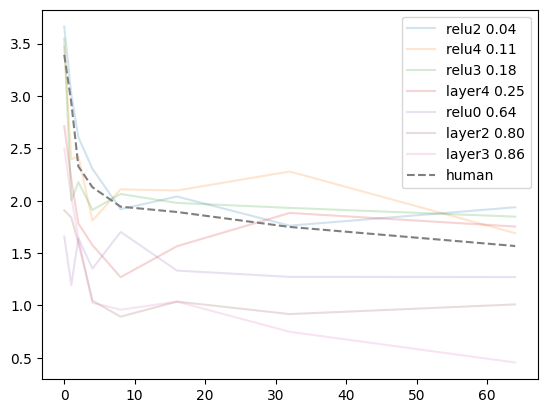

In [6]:
print(len(task_records))

for ts in task_records:

    if ts['metrics']['score'] < 1:
        print(ts['metrics'], ts['params']['layer'])
        plt.plot(isis, ts['model_dp'], alpha=0.2, label=f"{ts['params']['layer']} {ts['metrics']['score']:.2f}")


plt.plot(isis, human_curve_multi, '--', label="human")
plt.legend()

# valid = [
#     r for r in task_records
#     if np.isfinite(r['metrics']["score"]) and layer in r["params"].get("layer")
# ]

# print(valid[0]['params'])


In [7]:
ts['metrics']

{'mse_per_isi': array([9.13572586, 6.44365154, 6.01676198, 4.18437112, 3.75069689,
        2.56959472, 3.80457393, 1.35845235]),
 'mse_early': 4.018300360590891,
 'mse_late': 3.614075163631211,
 'mse_mean': 4.018300360590891,
 'score': 4.084234822449713}

In [ ]:
layers = sorted({r["params"]["layer"] for r in task_records})

best_per_layer = []

for layer in layers:
    best_model = get_best_for_layer(
        task_records, human_curve_multi, isis, layer=layer
    )
    if best_model is None:
        continue

    best_per_layer.append({
        "layer": layer,
        "sigma0": best_model["params"].get("sigma0", np.nan),
        "sigma1": best_model["params"].get("sigma1", np.nan),
        "nmse": best_model["nmse"],
    })

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

for rec in best_per_layer:
    plt.scatter(
        rec["sigma0"],
        rec["sigma1"],
        s=80,
        label=f'{rec["layer"]} (NMSE={rec["nmse"]:.3f})'
    )
    plt.text(
        rec["sigma0"],
        rec["sigma1"],
        rec["layer"],
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.xlabel("sigma0")
plt.ylabel("sigma1")
plt.title("Best model parameters per layer")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

layers = sorted({r["params"]["layer"] for r in task_records})

plt.figure(figsize=(7,4))

for layer in layers:
    recs = [r for r in task_records if r["params"]["layer"] == layer]
    recs = [r for r in recs if np.isfinite(r.get("nmse", np.nan))]
    if not recs:
        continue

    # shuffle to simulate "as search proceeds"
    rng = np.random.default_rng(0)
    order = rng.permutation(len(recs))
    nmse = np.array([recs[i]["nmse"] for i in order], float)

    best_so_far = np.minimum.accumulate(nmse)
    plt.plot(best_so_far, label=layer)

plt.yscale("log")
plt.xlabel("Number of evaluated configs (random order)")
plt.ylabel("Best-so-far NMSE (log scale)")
plt.title("Search sufficiency by layer")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:


best_relu1 = get_best_for_layer(task_records, human_curve_multi, isis, layer="relu1")
best_relu2 = get_best_for_layer(task_records, human_curve_multi, isis, layer="relu2")
best_relu2 = get_best_for_layer(task_records, human_curve_multi, isis, layer="relu3")

best_relu4 = get_best_for_layer(task_records, human_curve_multi, isis, layer="relu4")

best_fc    = get_best_for_layer(task_records, human_curve_multi, isis, layer="relufc")

In [ ]:
np.linspace(0.1, 1, 10), np.geomspace(0.1, 1, 10)


In [ ]:
len(task_records[0]['run_out']['fa_by_t'][-1])